In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

In [9]:
N_particles = 500

# ---- STILE PAPER ----
mpl.rcParams.update({

    # Usa font LaTeX (coerente con paper)
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Dimensioni testo (standard journal)
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Spessori ottimizzati per stampa
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Tick dentro (stile PRL/JCP)
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    # Griglia molto leggera
    "grid.linestyle": ":",
    "grid.linewidth": 0.4,
    "grid.alpha": 0.5,

    # Legenda minimale
    "legend.frameon": False,
})

In [10]:
def pot_neg(x,lamb):
    return np.pow(x,-12) - np.pow(x,-6) - lamb/x

def pot_pos(x,lamb):
    return np.pow(x,-12) - np.pow(x,-6) + lamb/x

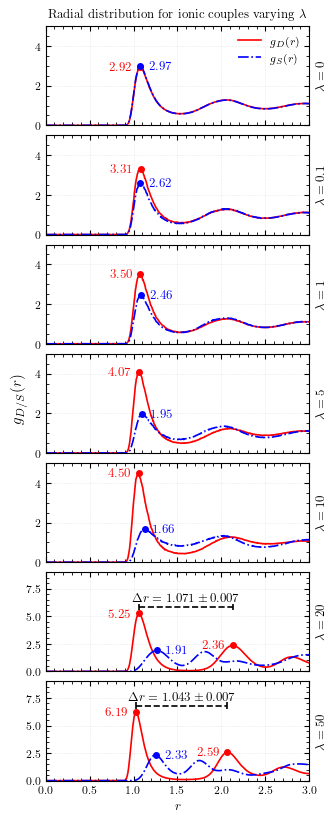

In [11]:
max_r_differ_array = []
max_g_differ_array = []

max_r_same_array = []
max_g_same_array = []

# 40%, 43%, 43%, 0.42%, 0.41%, 66%, 48%
lamb = [0, 0.1, 1,5,10,20,50]
n_lamb = np.size(lamb)

x = np.linspace(0.1,4,10000)

fig, axes = plt.subplots(n_lamb, 1, figsize=(3.4, (1.4)*n_lamb),sharex=True)
fig.subplots_adjust(hspace=0.1) 

axes[0].set_title(r'Radial distribution for ionic couples varying $\lambda$')

for i in range(0,n_lamb):
    l = lamb[i]
    y = pot_neg(x,l)
    y_2 = pot_pos(x,l)

    data_differ = np.loadtxt(f"./lambda{l}/radial_distribution_differ.csv", delimiter=";")
    axes[i].plot(data_differ[:,0], data_differ[:,1],c="red", label=r"$g_D(r)$")

    idx = np.argmax(data_differ[:, 1])
    row_max = data_differ[idx]

    x_max_diff = data_differ[idx, 0]
    y_max_diff = data_differ[idx, 1]
    max_r_differ_array.append(x_max_diff)
    max_g_differ_array.append(y_max_diff)

    data_same = np.loadtxt(f"./lambda{l}/radial_distribution_equal.csv", delimiter=";")
    axes[i].plot(data_same[:,0], data_same[:,1],c="blue", linestyle="-.", label =r"$g_S(r)$")

    idx = np.argmax(data_same[:, 1])
    row_max = data_same[idx]

    x_max_same = data_same[idx, 0]
    y_max_same = data_same[idx, 1]
    max_r_same_array.append(x_max_same)
    max_g_same_array.append(y_max_same)

    axes[i].text(
        x_max_diff - 0.35, y_max_diff,
        f'{y_max_diff:.2f}',
        va='center',
        ha='left',
        color="red"
    )
    axes[i].plot(x_max_diff, y_max_diff, "o",ms=4,color="red")

    axes[i].text(
        x_max_same + 0.1, y_max_same,
        f'{y_max_same:.2f}',
        va='center',
        ha='left',
        color="blue"
    )
    axes[i].plot(x_max_same, y_max_same, "o",ms=4,color="blue")

    axes[i].text(
        1.025, 0.5,
        rf'$\lambda = {l}$',
        transform=axes[i].transAxes,
        rotation=90,
        va='center',
        ha='left'
    )

    axes[i].set_xlim([0,3])
    axes[i].set_ylim([0,5])

    if i != n_lamb-1:
        axes[i].tick_params(axis='x', labelbottom=False)
    
    if i == n_lamb-1:
        axes[i].set_xlabel(r"$r$")

    if l >= 20:
        axes[i].set_ylim([0,9])

        # For last two plot the second maximum
        idx = np.argmax(data_differ[190:, 1]) + 190
        row_max = data_differ[idx]

        x_max_diff2 = data_differ[idx, 0]
        y_max_diff2 = data_differ[idx, 1]

        axes[i].text(
            x_max_diff2 - 0.35, y_max_diff2,
            f'{y_max_diff2:.2f}',
            va='center',
            ha='left',
            color="red"
        )
        axes[i].plot(x_max_diff2, y_max_diff2, "o",ms=4,color="red")

        delta_x = x_max_diff2 - x_max_diff
        
        y_line = max(y_max_diff, y_max_diff2) + 0.6

        axes[i].hlines(
            y=y_line,
            xmin=x_max_diff,
            xmax=x_max_diff2,
            colors='black',
            linestyles='--'
        )

        axes[i].text(
            (x_max_diff + x_max_diff2) / 2,
            y_line + 0.4,
            rf'$\Delta r = {delta_x:.3f}\pm0.007$',
            ha='center',
            va='bottom'
        )

        cap_height = 0.3
        axes[i].vlines(
            x=[x_max_diff, x_max_diff2],
            ymin=y_line - cap_height,
            ymax=y_line + cap_height,
            colors='black'
        )

    if l == 50:
        axes[i].set_ylim([0,9])

    if i == 0:
        axes[i].legend(loc='upper right')

    axes[i].xaxis.minorticks_on()
    axes[i].yaxis.minorticks_on()
    
    #axes[i].set_ylabel("g(r)")
    axes[i].grid()

fig.supylabel(r"$g_{D/S}(r)$") # ylabel in common

plt.savefig("lambda_coupling_styled.pdf", bbox_inches="tight")
plt.savefig("../../png/lambda_coupling_styled.png", bbox_inches="tight")

plt.show()



In [12]:
def autocorrelation_time(data, max_lag=None):

    data = np.asarray(data)
    N = len(data)

    if max_lag is None:
        max_lag = N // 2

    mean = np.mean(data)
    var = np.var(data)

    if var == 0:
        return 0.0

    autocorr = []

    for t in range(max_lag):
        c = np.mean((data[:N - t] - mean) * (data[t:] - mean)) / var
        autocorr.append(c)

    autocorr = np.array(autocorr)

    # sum until autocorrelation is positive
    positive = autocorr[1:][autocorr[1:] > 0]

    tau = 0.5 + np.sum(positive)
    return tau

tau: 291.1307469967742, -6.030787013516621 pm 0.006276489444286044, N eff = 42.93431775565258
tau: 74.17378896238463, -6.015640637984502 pm 0.006704642531584738, N eff = 67.40251603616164
tau: 72.51455576695557, -6.546071992208595 pm 0.006878394347306595, N eff = 68.94477870163333
tau: 158.38774458941356, -9.194705133578983 pm 0.011143202998623198, N eff = 31.564942180091883
tau: 124.90856684714058, -12.738272734711755 pm 0.010092174379609846, N eff = 40.02527709823331
tau: 123.52937350949009, -17.505356606102005 pm 0.005391650020845275, N eff = 60.71025689629887
tau: 316.55001176494335, -35.39320757463178 pm 0.00949586877085291, N eff = 23.691359094211034


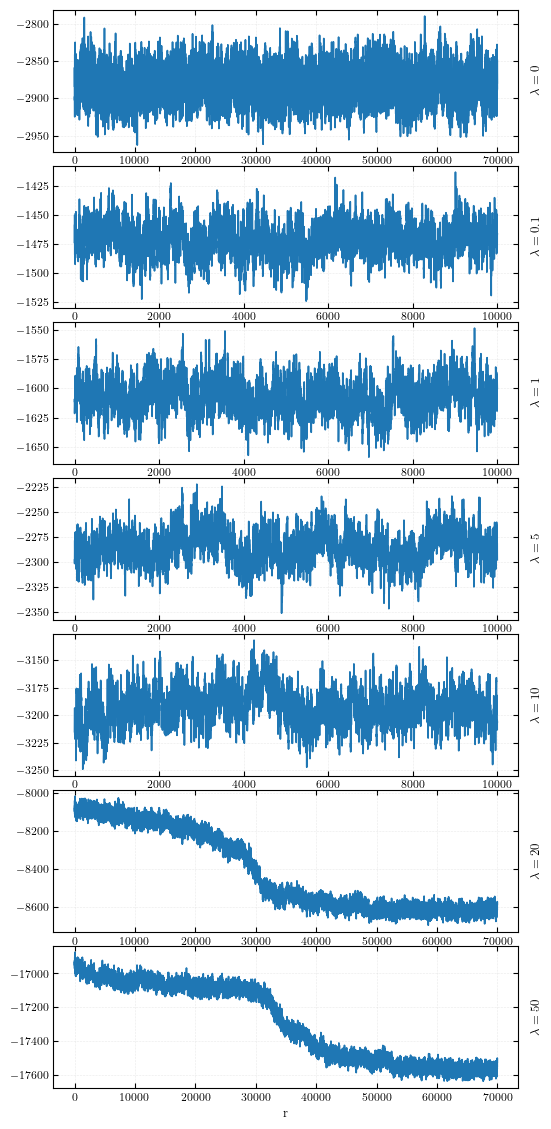

In [13]:
fig, axes = plt.subplots(n_lamb, 1, figsize=(6, 2*n_lamb))
fig.subplots_adjust(hspace=0.1) 

E_mean = []
E_std = []

for i in range(0,n_lamb):
    l = lamb[i]
    
    data_en = np.loadtxt(f"./lambda{l}/energy.csv", delimiter=";")
    energy_data = 0
    
    if(l <= 10 and l != 0):
        energy_data = (data_en[5000:] - 6.828018E+01)/256
    elif(l == 0):
        energy_data = (data_en[50000:] - 1.333597E+02)/500
    else:
        energy_data = (data_en[60000:]- 1.333597E+02)/500
    
    tau = autocorrelation_time(energy_data)

    print(f"tau: {tau}, {np.mean(energy_data)} pm {np.std(energy_data)*np.sqrt(2*tau/np.size(energy_data))}, N eff = {np.size(energy_data)/(2*tau)}")


    axes[i].plot(data_en[5000:])

    axes[i].text(
        1.025, 0.5,
        rf'$\lambda = {l}$',
        transform=axes[i].transAxes,
        rotation=90,
        va='center',
        ha='left'
    )
    
    if i == n_lamb-1:
        axes[i].set_xlabel("r")

    axes[i].grid()
    
plt.show()


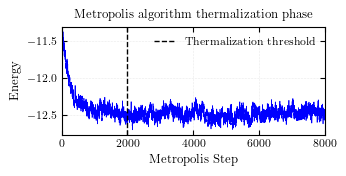

In [14]:
data = np.loadtxt("./lambda10/energy.csv", delimiter=";")

fig, axes = plt.subplots(figsize=(3.4, (1.4)))

plt.plot(data/256,ms=1,color="blue",lw=0.5)
plt.grid()
plt.title("Metropolis algorithm thermalization phase")
plt.ylabel("Energy")
plt.xlabel("Metropolis Step")
plt.axvline(x=2000, c="k", ls="--", lw=1, label="Thermalization threshold")

plt.xlim([0,8000])
plt.legend()

plt.savefig("equilibrization.pdf", bbox_inches="tight")
plt.savefig("../../png/equilibrization.png", bbox_inches="tight")